**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0007-3323-1760) · [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) · [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22)  
**Software:** [PyPI](https://pypi.org/user/nikhil.sunder/) · [Anaconda](https://anaconda.org/nikhil.sunder/)

# 3. Linear economy: TVP-SVAR(2) with stochastic volatility

The modern linear specification: a time-varying-parameter VAR(2) with stochastic volatility under the
same recursive ordering, estimated by Gibbs sampling. The notebook closes with the out-of-sample
comparison of all five linear environments.

**Inputs:** `artifacts/data/`, the one-step fits of notebooks `01` and `02`.
**Outputs:** `artifacts/linear/tvp_anchor.json` (the TVP economy frozen at the end of the estimation
window, for the reinforcement-learning notebooks), `artifacts/linear/one_step_tvp.csv`,
`artifacts/linear/oos_summary.csv`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cultivars.multivariate import TVPVARSV, TimeVaryingSVAR

import autofed as af
from autofed import linear as lin
from autofed import plots
from autofed.style import COLORS

nb = af.NotebookSession(
    "03_linear_tvp_svar_sv",
    number=3,
    title="Linear economy: TVP-SVAR(2) with stochastic volatility",
)
panel = af.load_macro_panel(nb.artifacts("data"))
cfg = panel.config
NAMES = list(af.NAMES)  # recursive ordering: y -> pi -> i
df_train, df_all = panel.train, panel.full
print(
    f"Data vintage {panel.retrieved} | training {df_train.index[0]}-{df_train.index[-1]} | "
    f"full {df_all.index[0]}-{df_all.index[-1]}"
)

df_tvp = panel.tvp  # training sample + initial lags + estimation sample
SHORT = {"y": "Output gap", "pi": "Inflation", "i": "Policy rate"}

Data vintage 2026-10-07 | training 1987Q3-2007Q2 | full 1987Q3-2026Q2


# Modern Specification: Recursive TVP-SVAR(2) with Stochastic Volatility (TVP-SVAR-SV)

This section replaces fixed-parameter estimation with a **time-varying parameter (TVP)** reduced form and
**stochastic volatility (SV)**. The aim is to allow (i) gradual drift in the reduced-form mapping and
(ii) time-varying shock uncertainty -- features commonly used to model evolving macroeconomic dynamics
and volatility (Cogley & Sargent, 2005; Primiceri, 2005). Relative to a rolling SVAR, TVP-SV treats
coefficient changes as **latent state evolution** rather than repeated re-estimation on a moving window
(Stock & Watson, 2007; Clements & Hendry, 1998).

Where the original notebook fitted two univariate TVP regressions with PyMC (ADVI initialisation, then
NUTS), `cultivars.multivariate.TVPVARSV` estimates the **joint three-variable system** by the Gibbs
sampler of Primiceri (2005), with the Carter–Kohn (1994) simulation smoother for the coefficient states
and the Kim–Shephard–Chib (1998) mixture block for the volatilities. To remain comparable to the baseline
recursive SVAR(2), the same **triangular (recursive) ordering** $y \to \pi \to i$ is declared at
estimation time (Sims, 1980; Lütkepohl, 2005).

## Model (observation equations)

Let $t=1,\dots,T$ index quarters and collect the observables in $x_t = (y_t, \pi_t, i_t)'$. The
reduced form is a VAR(2) whose coefficients drift:

$$
x_t = c_t + A_{1,t}\,x_{t-1} + A_{2,t}\,x_{t-2} + u_t,\qquad u_t \sim \mathcal{N}(0,\Sigma_t),
$$

or, stacking each equation's regressors as $X_t = [1, y_{t-1}, \pi_{t-1}, i_{t-1}, y_{t-2}, \pi_{t-2}, i_{t-2}]$,
$x_{m,t} = X_t\,\beta^m_t + u_{m,t}$ for $m \in \{y, \pi, i\}$.

### Recursive structure
The innovation covariance is factorized as $\Sigma_t = A^{-1} H_t A^{-\prime}$ with $A$ lower triangular
with unit diagonal and $H_t$ diagonal. Under the ordering $y \to \pi \to i$ the second row of
$A u_t = H_t^{1/2}\epsilon_t$ reads

$$
u_{\pi,t} = a^\pi_{y,0}\,u_{y,t} + h_{\pi,t}^{1/2}\epsilon_{\pi,t},\qquad a^\pi_{y,0} = (A^{-1})_{\pi y},
$$

so the structural inflation equation contains contemporaneous $y_t$ exactly as in the baseline, and the
inflation fitted value **conditional on realized $y_t$** is $X_t\beta^\pi_t + a^\pi_{y,0}(y_t - X_t\beta^y_t)$.
Throughout, the specification is interpreted as a **reduced-form** environment rather than a fully
structural causal model.

## State evolution (time variation in coefficients)

The stacked coefficient vector $\beta_t = (\beta^y_t, \beta^\pi_t, \beta^i_t)$ follows a random walk:
$$
\beta_t = \beta_{t-1} + \nu_t, \qquad \nu_t \sim \mathcal{N}(0,Q).
$$
This state equation captures gradual parameter drift in the spirit of standard TVP macroeconometric
specifications (Cogley & Sargent, 2005; Primiceri, 2005).

## Stochastic volatility (SV)

Each orthogonalized disturbance variance evolves over time via a log-variance random walk:
$$
h_{m,t} = h_{m,t-1} + \eta_{m,t},\qquad \eta_{m,t}\sim\mathcal{N}(0,W_m),\qquad
\sigma_{m,t} = \exp(h_{m,t}/2),
$$
with $H_t = \mathrm{diag}(\exp h_{y,t}, \exp h_{\pi,t}, \exp h_{i,t})$. Allowing $\sigma_{m,t}$ to vary
accommodates time-varying macro uncertainty and volatility consistent with empirical TVP-SV evidence
(Cogley & Sargent, 2005; Primiceri, 2005). In the `cultivars` implementation the triangular factor $A$ is
time-invariant, which is the specification the notebook's conditional-forecast construction requires.

## Inference (Gibbs sampling with the KSC mixture) and reported fitted values

TVP-SV models are high-dimensional because they infer full latent paths $\{\beta_t\}_{t=1}^T$ and
$\{h_{m,t}\}_{t=1}^T$. `TVPVARSV` samples the joint posterior by Gibbs:

1. **Coefficient states** $\beta_{1:T}$ by the Carter–Kohn (1994) forward-filter backward-sampler, given
   the volatilities and $A$.
2. **Log volatilities** $h_{1:T}$ by the Kim–Shephard–Chib (1998) seven-component mixture approximation to
   the log-$\chi^2$ likelihood, given the states.
3. **The triangular factor** $A$ and the innovation variances $Q$, $W$ from their conjugate conditionals.

**Prior calibration.** Following Primiceri (2005), the priors for $\beta_0$, $A$, $\log\sigma_0$ and the
scales of $Q$ and $W$ are calibrated on a **training sample** (the 40 quarters before 1987Q3), which is then
discarded. `k_drift` and `k_vol` are Primiceri's $k_Q$ and $k_W$ (both 0.01 here).

**Chains.** Two independent chains of 3,000 draws (1,500 burn-in, thinning 2) are run from different seeds.
The second chain exists to assess convergence with split R-hat and effective-sample-size diagnostics;
all reported paths come from the first.

For each equation $m$ we report the posterior mean fitted path
$$
\hat{x}_t^{m} \equiv \mathbb{E}\!\left[X_t\beta_t^{m}\mid \text{data}\right],
$$
and pointwise 90% credible bands for $\mu_t^{m}=X_t\beta_t^{m}$ computed from posterior quantiles. Because
the Gibbs draws condition on the whole sample, these are **smoothed (two-sided)** fits: over 2007Q3
onward they describe how a drifting linear environment reads the realized data, not a real-time
forecast, and they are therefore not on the same footing as the fixed, rolling and expanding
environments.

## Implementation: estimation sample alignment (matches baseline/rolling SVAR)

The model is given the panel from 1977Q1, of which the first 40 rows are the training sample and the next
two supply the initial lags. Its estimation sample is therefore 1987Q3 onward -- the same rows the
baseline VAR and the rolling and expanding loops use -- and the same per-equation regressor block
$[1, y_{t-1}, \pi_{t-1}, i_{t-1}, y_{t-2}, \pi_{t-2}, i_{t-2}]$ as the `cultivars` reduced form. The
alignment is asserted, not assumed.

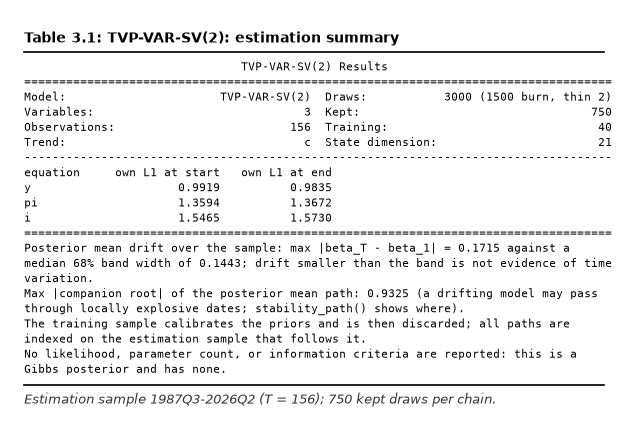

In [2]:
TVP_DRAWS = {"n_draws": 3000, "n_burn": 1500, "thin": 2, "k_drift": 0.01, "k_vol": 0.01}
K_TRAIN = cfg.tvp_training_quarters

tvp_model = TVPVARSV(
    df_tvp[NAMES].to_numpy(), order=2, training=K_TRAIN, trend="c", names=NAMES
)
tvp = tvp_model.fit(seed=123, **TVP_DRAWS)  # reported chain
tvp_chain2 = tvp_model.fit(
    seed=456, **TVP_DRAWS
)  # independent chain, for convergence assessment only

# Estimation-sample index: rows after the training sample and the two initial lags
tvp_index = df_tvp.index[K_TRAIN + tvp.order :]
assert len(tvp_index) == tvp.nobs and tvp_index[0] == pd.Period(cfg.train_start, "Q")
nb.listing(
    str(tvp.summary()),
    "tvp_summary",
    "TVP-VAR-SV(2): estimation summary",
    note=(
        f"Estimation sample {tvp_index[0]}-{tvp_index[-1]} (T = {tvp.nobs}); {tvp.n_kept} kept"
        " draws per chain."
    ),
)

### Sampler convergence

`convergence()` pools the two chains and reports split R-hat, bulk and tail effective sample sizes and
the Monte Carlo standard error for every retained quantity (coefficient states, log volatilities, and the
free entries of $A$). Volatility states in Gibbs samplers of this kind mix slowly, so some flagged
quantities are expected at this chain length; the summary lists the worst twenty, and the counts below
show how much of each block is affected. The diagonal of $A$ is fixed at one by construction and is
reported as degenerate rather than assessed.

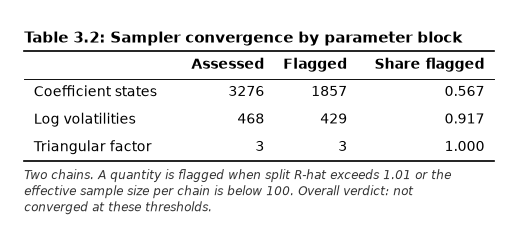

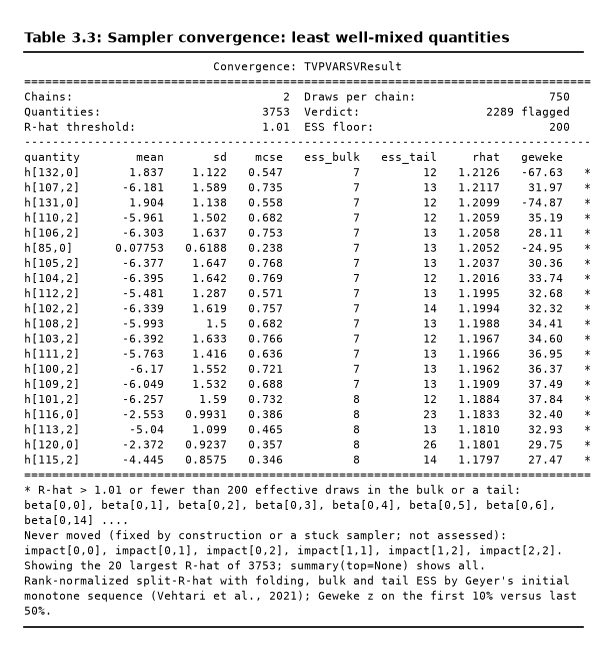

In [3]:
convergence = tvp.convergence(tvp_chain2)
flagged, degenerate = set(convergence.flagged), set(convergence.degenerate)
blocks = {}
for block, shown in (
    ("beta", "Coefficient states"),
    ("h", "Log volatilities"),
    ("impact", "Triangular factor"),
):
    members = [
        n for n in convergence.names if n.startswith(f"{block}[") and n not in degenerate
    ]
    n_flagged = sum(n in flagged for n in members)
    blocks[shown] = {
        "Assessed": len(members),
        "Flagged": n_flagged,
        "Share flagged": n_flagged / max(len(members), 1),
    }
blocks = pd.DataFrame(blocks).T.astype({"Assessed": int, "Flagged": int})
nb.table(
    blocks,
    "tvp_convergence",
    "Sampler convergence by parameter block",
    note=(
        f"Two chains. A quantity is flagged when split R-hat exceeds {convergence.rhat_tol} or"
        f" the effective sample size per chain is below {convergence.min_ess:.0f}. Overall"
        " verdict: "
    )
    + ("converged." if convergence.converged else "not converged at these thresholds."),
)
nb.listing(
    str(convergence.summary()),
    "tvp_convergence_detail",
    "Sampler convergence: least well-mixed quantities",
)

## Estimation: fitted paths and squared errors

Steps performed below:

1. Rebuild the per-equation regressor matrix $X_t$ on the estimation sample and verify that
   $X_t\,\bar\beta_t$ reproduces `fittedvalues` exactly.
2. Form the posterior draws of the conditional means $\mu^y_t = X_t\beta^y_t$ and
   $\mu^\pi_t = X_t\beta^\pi_t$, and of the contemporaneous coefficient $a^\pi_{y,0} = (A^{-1})_{\pi y}$.
3. Make the inflation fit **conditional on realized $y_t$** draw by draw:
   $\mu^{\pi\mid y}_t = \mu^\pi_t + a^\pi_{y,0}\,(y_t - \mu^y_t)$.
4. Report posterior means and 5th–95th percentile bands, and compute **in-sample squared errors** over
   the training window (1987Q3–2007Q2):
   $$
   SE_t^y = (y_t-\hat y_t)^2,\qquad SE_t^\pi = (\pi_t-\hat \pi_t)^2.
   $$

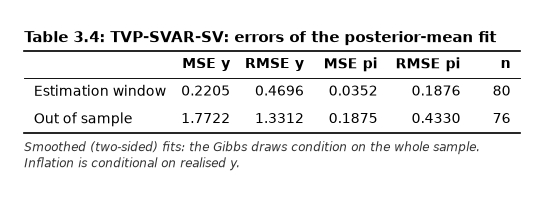

In [4]:
fit_tvp = lin.tvp_conditional_fit(tvp, df_tvp, training=K_TRAIN)
assert fit_tvp.index.equals(tvp_index)
af.save_frame(fit_tvp, nb.artifacts("linear") / "one_step_tvp.csv")

tvp_is = fit_tvp.loc[cfg.train_start : cfg.train_end]
tvp_oos = fit_tvp.loc[cfg.oos_start :]
tvp_metrics = pd.DataFrame({
    "Estimation window": lin.error_metrics(tvp_is),
    "Out of sample": lin.error_metrics(tvp_oos),
}).T
tvp_metrics["n"] = tvp_metrics["n"].astype(int)
nb.table(
    tvp_metrics,
    "tvp_error_metrics",
    "TVP-SVAR-SV: errors of the posterior-mean fit",
    float_format="{:.4f}",
    note=(
        "Smoothed (two-sided) fits: the Gibbs draws condition on the whole sample. Inflation is"
        " conditional on realised y."
    ),
)

## In-sample squared-error diagnostics

The two figures repeat the fit-quality diagnostics of notebook `01_linear_svar` for the TVP-SV
environment: squared errors of the output gap, and of inflation conditional on the realised output gap.

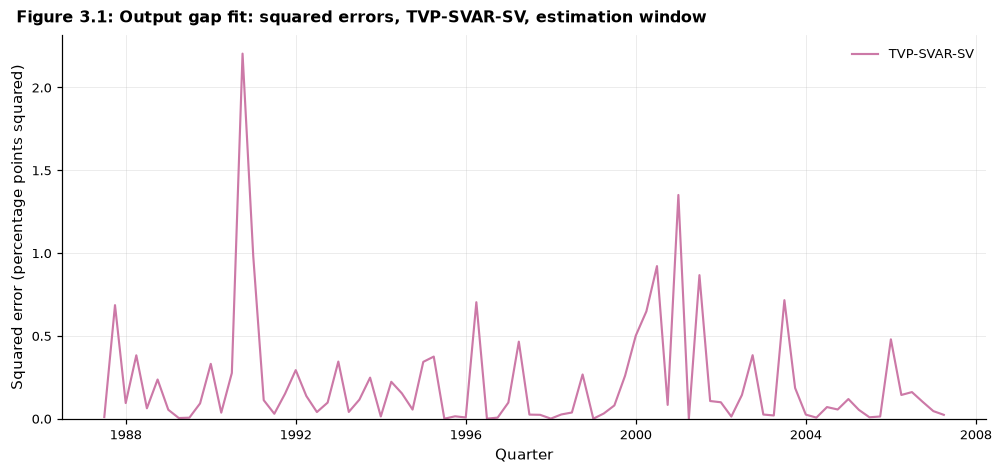

In [5]:
fig = plots.squared_errors(
    {"TVP-SVAR-SV": (tvp_is["y"] - tvp_is["y_hat"]) ** 2}, colors=[COLORS["purple"]]
)
nb.figure(
    fig, "tvp_se_output_gap", "Output gap fit: squared errors, TVP-SVAR-SV, estimation window"
)

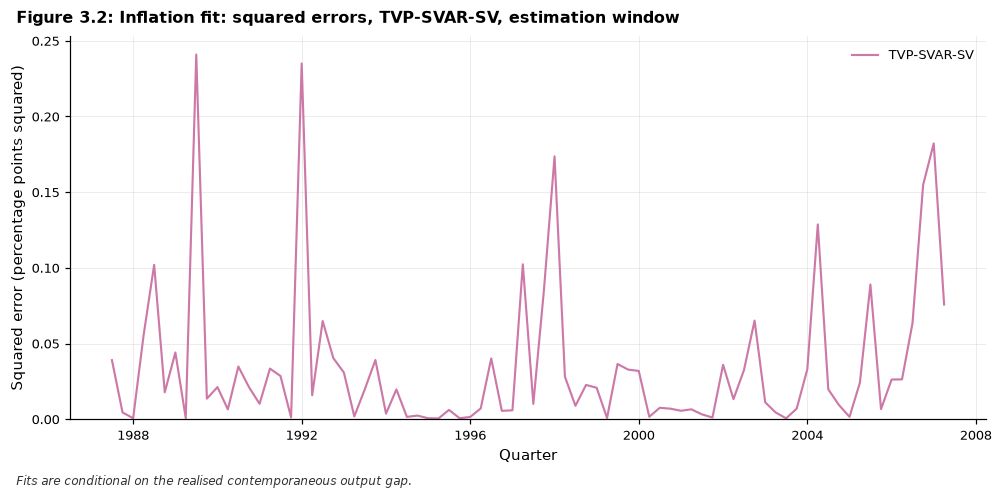

In [6]:
fig = plots.squared_errors(
    {"TVP-SVAR-SV": (tvp_is["pi"] - tvp_is["pi_hat"]) ** 2}, colors=[COLORS["purple"]]
)
nb.figure(
    fig,
    "tvp_se_inflation",
    "Inflation fit: squared errors, TVP-SVAR-SV, estimation window",
    note="Fits are conditional on the realised contemporaneous output gap.",
)

## Out-of-sample evaluation (2007Q3+) and uncertainty bands

We evaluate the TVP fitted paths over the out-of-sample period (2007Q3 onward) using:

- errors and squared errors:
  $$
  e_t^m = x_t^m - \hat x_t^m,\quad SE_t^m=(e_t^m)^2,\quad m\in\{y,\pi\},
  $$
- summary metrics: MSE and RMSE over the out-of-sample span.

**Credible bands:** the pointwise 5th–95th posterior percentiles of the conditional mean
$\mu_t = X_t\beta_t$ (and of its $y_t$-conditional counterpart for inflation) reflect posterior
uncertainty about the fitted conditional-mean path, not a full predictive interval that would also add
the time-varying observation noise $\sigma_{m,t}$.

## Out-of-sample tracking with posterior bands

Realised series against the posterior-mean fitted path, with pointwise 90% credible bands for the
conditional mean.

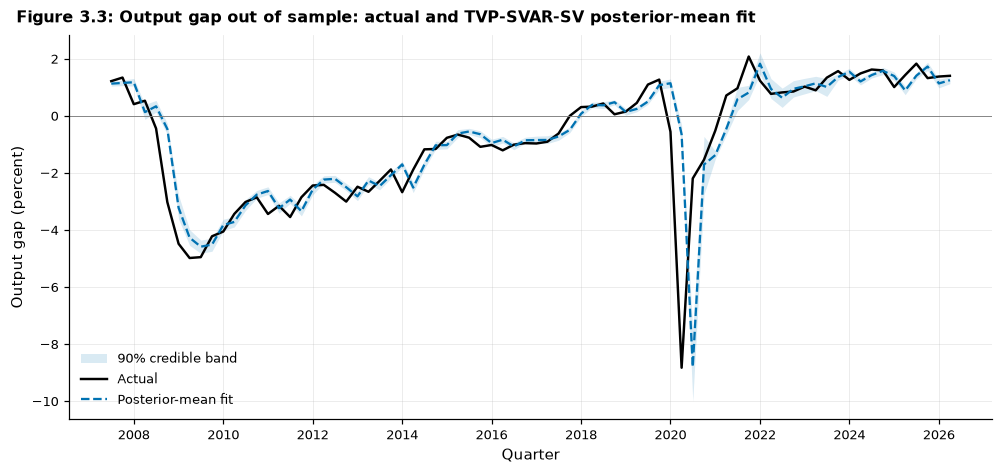

In [7]:
fig = plots.actual_vs_fit(
    tvp_oos,
    "y",
    {"Posterior-mean fit": "y_hat"},
    bands=("y_hat_lo", "y_hat_hi"),
    band_label="90% credible band",
)
nb.figure(
    fig,
    "tvp_oos_output_gap",
    "Output gap out of sample: actual and TVP-SVAR-SV posterior-mean fit",
)

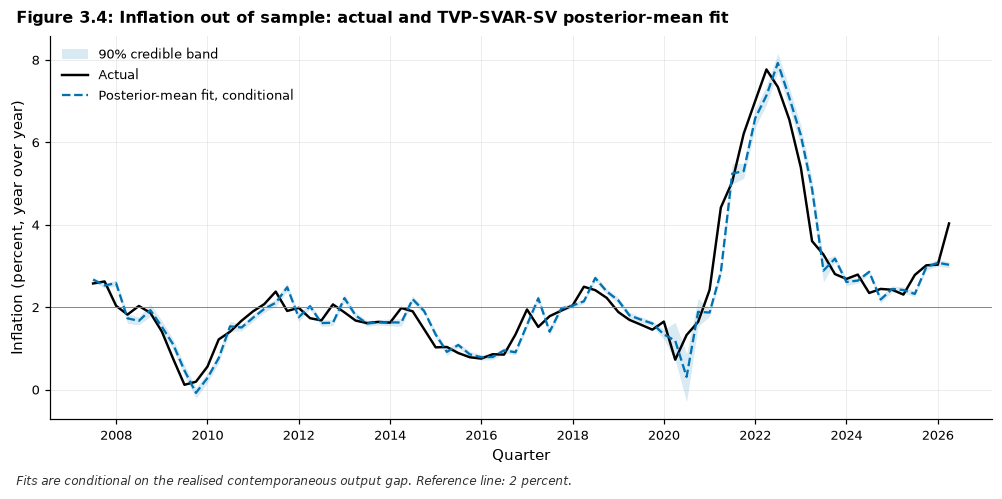

In [8]:
fig = plots.actual_vs_fit(
    tvp_oos,
    "pi",
    {"Posterior-mean fit, conditional": "pi_hat"},
    bands=("pi_hat_lo", "pi_hat_hi"),
    band_label="90% credible band",
)
nb.figure(
    fig,
    "tvp_oos_inflation",
    "Inflation out of sample: actual and TVP-SVAR-SV posterior-mean fit",
    note=(
        "Fits are conditional on the realised contemporaneous output gap. Reference line: 2"
        " percent."
    ),
)

## What the TVP model adds: drift and volatility

Three things a fixed-coefficient environment cannot show. First, the posterior path of individual
coefficients with 68% bands: the own-lag persistence of inflation and of the output gap, and the two
cross-equation channels a policy-learning agent cares about (the output gap's response to the lagged
policy rate and inflation's response to the lagged output gap). Second, the innovation standard deviation
of each equation over time: the Great Moderation, the crisis and 2020 are visible as volatility, not as
coefficient change. Third, the largest companion root of the posterior-mean coefficient path, which shows
whether the drifting environment passes through locally explosive dates.

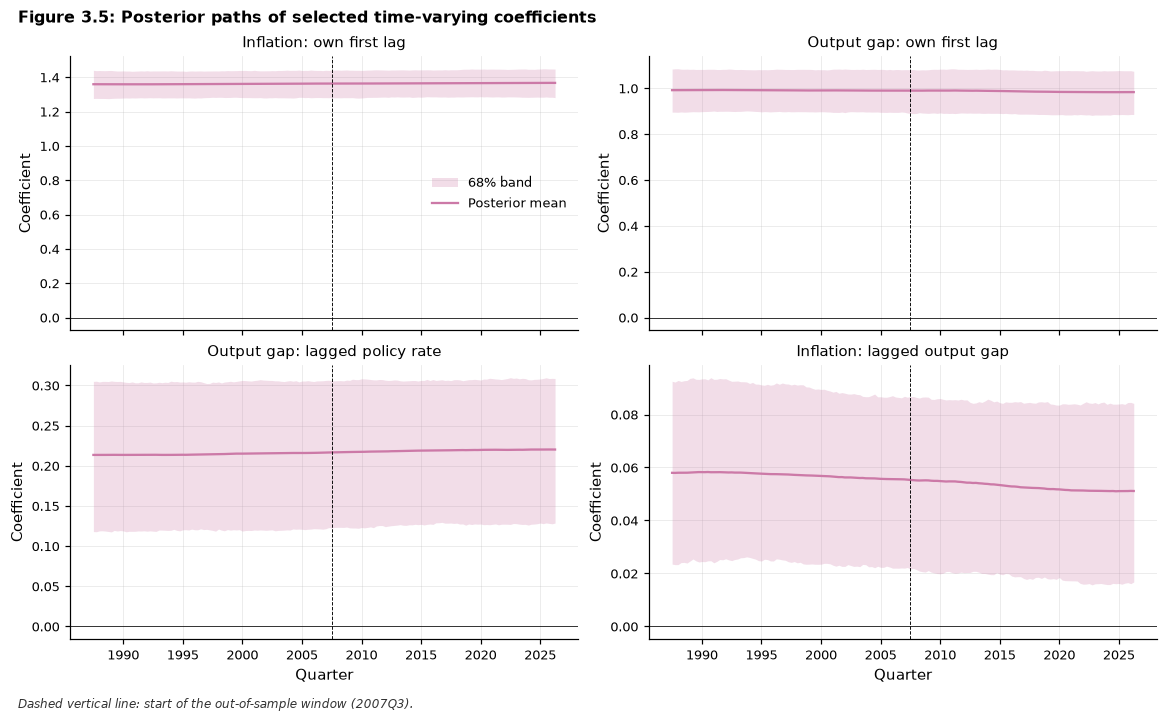

In [9]:
dates = tvp_index.to_timestamp()
oos_line = pd.Period(cfg.oos_start, "Q").to_timestamp()

panels = [
    ("pi", "pi.L1", "Inflation: own first lag"),
    ("y", "y.L1", "Output gap: own first lag"),
    ("y", "i.L1", "Output gap: lagged policy rate"),
    ("pi", "y.L1", "Inflation: lagged output gap"),
]
fig, axes = plt.subplots(2, 2, figsize=(10.5, 6.2), sharex=True)
for ax, (eq, reg, title) in zip(axes.ravel(), panels):
    low, mean, high = tvp.coefficient_path(eq, reg).T
    ax.fill_between(
        dates, low, high, color=COLORS["purple"], alpha=0.25, lw=0, label="68% band"
    )
    ax.plot(dates, mean, color=COLORS["purple"], label="Posterior mean")
    ax.axhline(0.0, color=COLORS["black"], lw=0.5)
    ax.axvline(oos_line, color=COLORS["black"], lw=0.6, ls="--")
    ax.set_title(title)
    ax.set_ylabel("Coefficient")
for ax in axes[-1]:
    ax.set_xlabel("Quarter")
axes[0, 0].legend(loc="best")
nb.figure(
    fig,
    "tvp_coefficient_paths",
    "Posterior paths of selected time-varying coefficients",
    note=f"Dashed vertical line: start of the out-of-sample window ({cfg.oos_start}).",
)

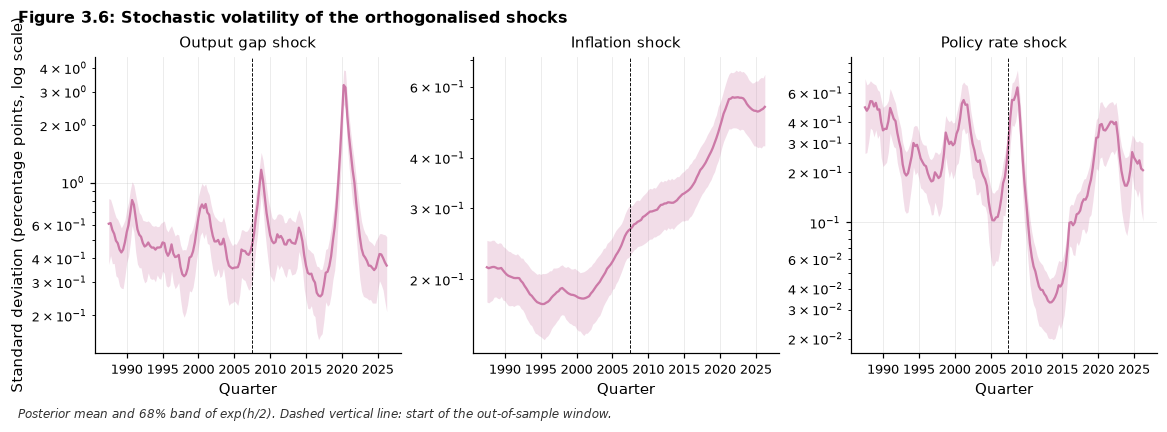

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6), sharex=True)
for ax, name in zip(axes, NAMES):
    low, mean, high = tvp.volatility_path(name).T
    ax.fill_between(dates, low, high, color=COLORS["purple"], alpha=0.25, lw=0)
    ax.plot(dates, mean, color=COLORS["purple"])
    ax.axvline(oos_line, color=COLORS["black"], lw=0.6, ls="--")
    ax.set_yscale("log")
    ax.set_title(f"{SHORT[name]} shock")
    ax.set_xlabel("Quarter")
axes[0].set_ylabel("Standard deviation (percentage points, log scale)")
nb.figure(
    fig,
    "tvp_volatility_paths",
    "Stochastic volatility of the orthogonalised shocks",
    note=(
        "Posterior mean and 68% band of exp(h/2). Dashed vertical line: start of the"
        " out-of-sample window."
    ),
)

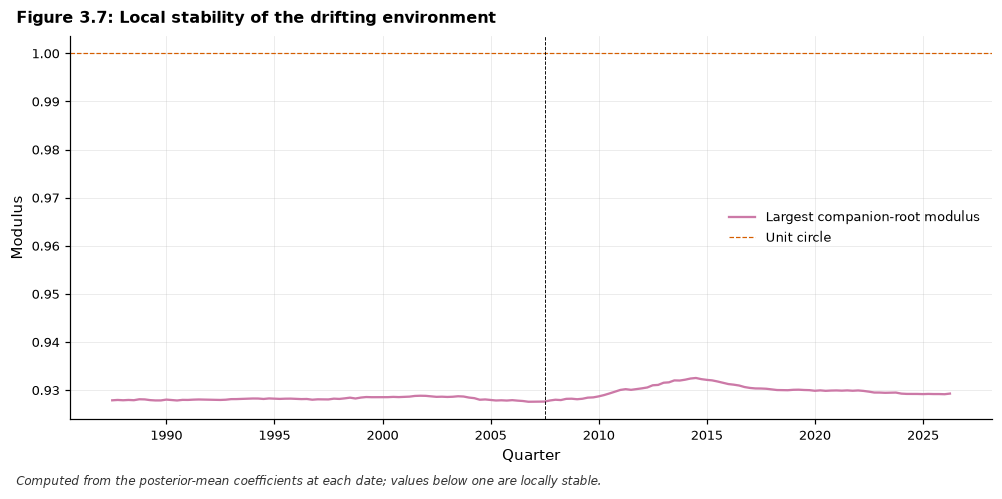

In [11]:
fig, ax = plt.subplots()
ax.plot(
    dates, tvp.stability_path(), color=COLORS["purple"], label="Largest companion-root modulus"
)
ax.axhline(1.0, color=COLORS["vermillion"], lw=0.8, ls="--", label="Unit circle")
ax.axvline(oos_line, color=COLORS["black"], lw=0.6, ls="--")
ax.set_xlabel("Quarter")
ax.set_ylabel("Modulus")
ax.legend()
nb.figure(
    fig,
    "tvp_stability_path",
    "Local stability of the drifting environment",
    note=(
        "Computed from the posterior-mean coefficients at each date; values below one are"
        " locally stable."
    ),
)

### Time-varying transmission of a policy-rate shock

`TimeVaryingSVAR` freezes the posterior-mean coefficients and impact matrix at a chosen date and returns
the impulse responses prevailing there. Comparing the responses of the output gap and inflation to a
one-standard-deviation policy-rate shock at three dates -- the early training sample, the trough of the
financial crisis and the post-pandemic tightening -- shows how much of the environment's transmission
mechanism the drift has moved. The responses are exact only while parameters do not drift over the
horizon, and the shock size itself varies with $\sigma_{i,t}$.

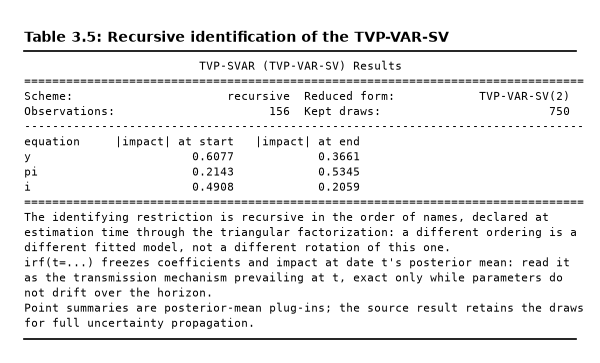

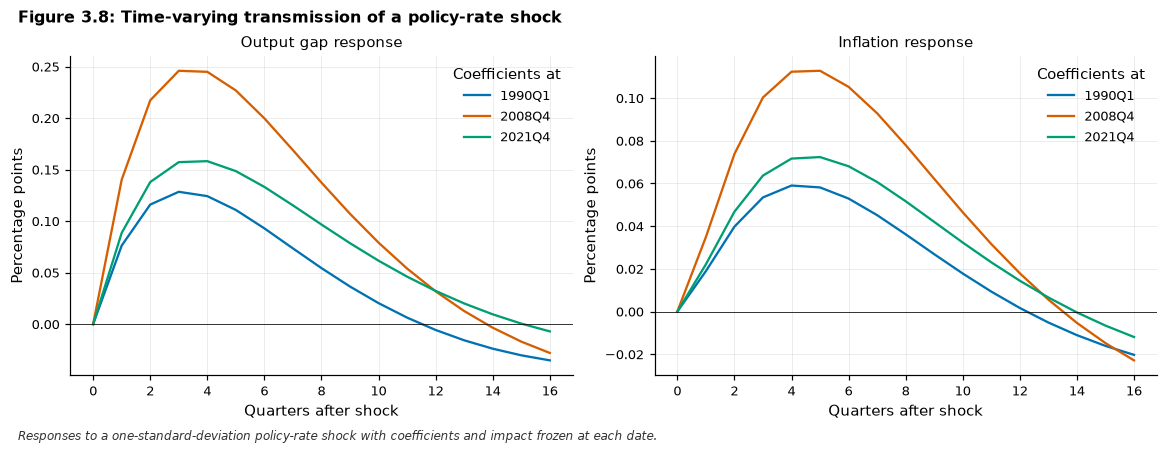

In [12]:
IRF_H = 16
tvsvar = TimeVaryingSVAR(tvp).identify()
nb.listing(
    str(tvsvar.summary()), "tvp_identification", "Recursive identification of the TVP-VAR-SV"
)

IRF_DATES = [d for d in ("1990Q1", "2008Q4", "2021Q4") if pd.Period(d, "Q") in tvp_index]
horizon = np.arange(IRF_H + 1)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for date in IRF_DATES:
    response = tvsvar.irf(
        IRF_H, t=tvp_index.get_loc(pd.Period(date, "Q"))
    )  # (horizon + 1, variable, shock)
    axes[0].plot(horizon, response[:, 0, 2], label=date)
    axes[1].plot(horizon, response[:, 1, 2], label=date)
for ax, title in zip(axes, ("Output gap", "Inflation")):
    ax.axhline(0.0, color=COLORS["black"], lw=0.5)
    ax.set_title(f"{title} response")
    ax.set_xlabel("Quarters after shock")
    ax.set_ylabel("Percentage points")
    ax.legend(title="Coefficients at")
nb.figure(
    fig,
    "tvp_policy_shock_irf",
    "Time-varying transmission of a policy-rate shock",
    note=(
        "Responses to a one-standard-deviation policy-rate shock with coefficients and impact"
        " frozen at each date."
    ),
)

## The TVP economy at the end of the estimation window

For policy experiments the drifting model is frozen at one date. Under the triangular factorisation the
two structural equations follow from the reduced form exactly as in the baseline:
$a^\pi_{y,0} = (A^{-1})_{\pi y}$, $b^\pi = \beta^\pi_T - a^\pi_{y,0}\beta^y_T$, and the shock scales are
the posterior means of $\exp(h_{m,T}/2)$. The table sets the anchored coefficients beside the restricted
SVAR of notebook `01_linear_svar`; the specification is saved for the reinforcement-learning notebooks.
Because the Gibbs draws condition on the whole sample, the anchor contains some post-2007 information.

Saved artifacts/linear/tvp_anchor.json


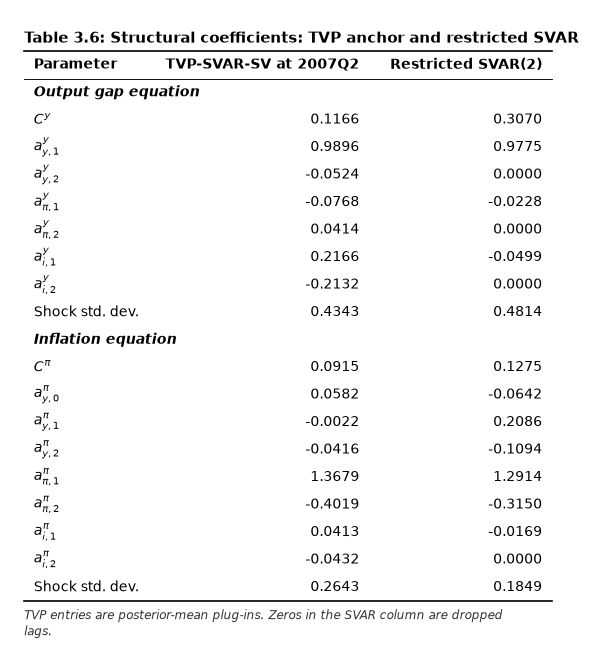

In [13]:
anchor_period = pd.Period(cfg.train_end, "Q")
anchor = lin.tvp_structural_spec(
    tvp,
    int(tvp_index.get_loc(anchor_period)),
    label=f"TVP-SVAR-SV at {anchor_period}",
    anchor=str(anchor_period),
    vintage=panel.retrieved,
    **TVP_DRAWS,
)
print(
    "Saved",
    anchor.save(nb.artifacts("linear") / "tvp_anchor.json").relative_to(nb.workspace.root),
)
svar_spec = lin.RecursiveLinearSpec.load(nb.artifacts("linear") / "svar_restricted.json")

rows = {}
for eq, title in (("y", "Output gap equation"), ("pi", "Inflation equation")):
    for name in anchor.series(eq).index:
        rows[(title, lin.PARAMETER_TEX[eq][name])] = {
            anchor.label: anchor.series(eq)[name],
            "Restricted SVAR(2)": svar_spec.series(eq)[name],
        }
    rows[(title, "Shock std. dev.")] = {
        anchor.label: anchor.sigma_y if eq == "y" else anchor.sigma_pi,
        "Restricted SVAR(2)": svar_spec.sigma_y if eq == "y" else svar_spec.sigma_pi,
    }
anchor_table = pd.DataFrame.from_dict(rows, orient="index")
anchor_table.index = pd.MultiIndex.from_tuples(
    anchor_table.index, names=["Equation", "Parameter"]
)
nb.table(
    anchor_table,
    "tvp_anchor_coefficients",
    "Structural coefficients: TVP anchor and restricted SVAR",
    float_format="{:.4f}",
    note="TVP entries are posterior-mean plug-ins. Zeros in the SVAR column are dropped lags.",
)

# Summary of out-of-sample performance

One-step MSE and RMSE from 2007Q3 across the five environments. All use realized lags and inflation
conditional on realized $y_t$. The fixed, rolling and expanding rows are real-time forecasts and are
directly comparable (the model confidence set above states which of them the evaluation window can
separate); the TVP row is a smoothed (two-sided) posterior fit and is reported for completeness rather
than as a competitor.

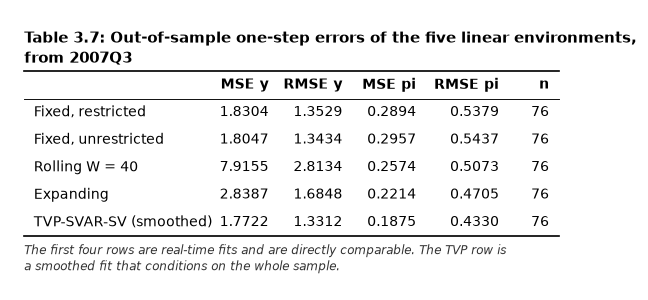

In [14]:
fixed = af.load_frame(
    nb.artifacts("linear") / "one_step_fixed.csv", producer="notebook 01_linear_svar"
)
rolling = af.load_frame(
    nb.artifacts("linear") / "one_step_rolling.csv",
    producer="notebook 02_linear_rolling_expanding",
)
expanding = af.load_frame(
    nb.artifacts("linear") / "one_step_expanding.csv",
    producer="notebook 02_linear_rolling_expanding",
)
oos = slice(cfg.oos_start, None)

summary = pd.DataFrame({
    "Fixed, restricted": lin.error_metrics(fixed.loc[oos]),
    "Fixed, unrestricted": lin.error_metrics(fixed.loc[oos], "y_hat_unres", "pi_hat_unres"),
    "Rolling W = 40": lin.error_metrics(rolling.loc[oos].dropna()),
    "Expanding": lin.error_metrics(expanding.loc[oos].dropna()),
    "TVP-SVAR-SV (smoothed)": lin.error_metrics(tvp_oos),
}).T
summary["n"] = summary["n"].astype(int)
summary.to_csv(nb.artifacts("linear") / "oos_summary.csv")
nb.table(
    summary,
    "oos_summary",
    f"Out-of-sample one-step errors of the five linear environments, from {cfg.oos_start}",
    float_format="{:.4f}",
    note=(
        "The first four rows are real-time fits and are directly comparable. The TVP row is a"
        " smoothed fit that conditions on the whole sample."
    ),
)

## Reading the comparison

The fixed-coefficient environment of the paper is a one-step mapping estimated once on a pre-crisis
window; its out-of-sample errors are the cost of holding that mapping fixed through the financial crisis,
the effective-lower-bound decade and the post-pandemic inflation. The re-estimation schemes ask whether
letting the mapping move helps: the expanding scheme keeps every observation and drifts slowly, the
rolling scheme forgets and adapts faster at the price of noisier coefficients, and the formal tests above
say whether the window can distinguish them at all. The TVP-SVAR-SV closes the section by showing where
the changes are: in the volatility of the shocks far more than in the coefficients that map the state
into next quarter's output gap and inflation, which is the property that makes a linear environment a
defensible benchmark for the policy-learning exercise it feeds.

# References (APA)

## Software

1. Sunder, N. (2026). cultivars: Research-grade time series econometrics for Python (v1.0.0a1). https://pypi.org/project/cultivars/
2. Sunder, N. (2025). fedfred: A Python client for the Federal Reserve Economic Database (FRED) API (v3.0.0). Zenodo. https://doi.org/10.5281/zenodo.17635942
3. The pandas development team. (2026). pandas-dev/pandas: Pandas. Zenodo. https://doi.org/10.5281/zenodo.18675244
4. Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., Fernández del Río, J., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C., & Oliphant, T. E. (2020). Array programming with NumPy. *Nature*, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2
5. Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., … SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. https://doi.org/10.1038/s41592-019-0686-2
6. The Matplotlib Development Team. (2025). Matplotlib: Visualization with Python. Zenodo. https://doi.org/10.5281/zenodo.17595503
7. Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. In *Proceedings of the 9th Python in Science Conference* (pp. 92–96). https://doi.org/10.25080/Majora-92bf1922-011
8. Kluyver, T., Ragan-Kelley, B., Pérez, F., Granger, B., Bussonnier, M., Frederic, J., Kelley, K., Hamrick, J., Grout, J., Corlay, S., Ivanov, P., Avila, D., Abdalla, S., Willing, C., & Jupyter Development Team. (2016). Jupyter Notebooks – a publishing format for reproducible computational workflows. In *Positioning and Power in Academic Publishing: Players, Agents and Agendas* (pp. 87–90). IOS Press. https://doi.org/10.3233/978-1-61499-649-1-87
9. Python Software Foundation. (2025). Python (Version 3.13) [Computer software]. https://www.python.org/

## Papers & Books

1. Hinterlang, N., & Tänzer, A. (2021). Optimal monetary policy using reinforcement learning. *SSRN*. https://doi.org/10.2139/ssrn.4013384
2. Sims, C. A. (1980). Macroeconomics and reality. *Econometrica*, 48(1), 1–48. https://doi.org/10.2307/1912017
3. Lütkepohl, H. (2005). *New introduction to multiple time series analysis*. Springer. https://doi.org/10.1007/3-540-27752-8
4. Clements, M. P., & Hendry, D. F. (1998). *Forecasting economic time series*. Cambridge University Press. https://doi.org/10.1017/CBO9780511599286
5. Stock, J. H., & Watson, M. W. (2007). Why has U.S. inflation become harder to forecast? *Journal of Money, Credit and Banking*, 39(s1), 3–33. https://doi.org/10.1111/j.1538-4616.2007.00014.x
6. Cogley, T., & Sargent, T. J. (2005). Drifts and volatilities: Monetary policies and outcomes in the post WWII US. *Review of Economic Dynamics*, 8(2), 262–302. https://doi.org/10.1016/j.red.2004.10.009
7. Primiceri, G. E. (2005). Time varying structural vector autoregressions and monetary policy. *Review of Economic Studies*, 72(3), 821–852. https://doi.org/10.1111/j.1467-937X.2005.00353.x
8. Hamilton, J. D. (1994). *Time series analysis*. Princeton University Press.
9. Giacomini, R., & White, H. (2006). Tests of conditional predictive ability. *Econometrica*, 74(6), 1545–1578. https://doi.org/10.1111/j.1468-0262.2006.00718.x
10. Carter, C. K., & Kohn, R. (1994). On Gibbs sampling for state space models. *Biometrika*, 81(3), 541–553. https://doi.org/10.1093/biomet/81.3.541
11. Kim, S., Shephard, N., & Chib, S. (1998). Stochastic volatility: Likelihood inference and comparison with ARCH models. *Review of Economic Studies*, 65(3), 361–393. https://doi.org/10.1111/1467-937X.00050
12. Kim, C.-J., & Nelson, C. R. (1999). *State-space models with regime switching: Classical and Gibbs-sampling approaches with applications*. MIT Press.
13. Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics*, 13(3), 253–263. https://doi.org/10.1080/07350015.1995.10524599
14. Harvey, D., Leybourne, S., & Newbold, P. (1997). Testing the equality of prediction mean squared errors. *International Journal of Forecasting*, 13(2), 281–291. https://doi.org/10.1016/S0169-2070(96)00719-4
15. Hansen, P. R., Lunde, A., & Nason, J. M. (2011). The model confidence set. *Econometrica*, 79(2), 453–497. https://doi.org/10.3982/ECTA5771
16. Mincer, J., & Zarnowitz, V. (1969). The evaluation of economic forecasts. In J. Mincer (Ed.), *Economic forecasts and expectations: Analysis of forecasting behavior and performance* (pp. 3–46). NBER.
17. Waggoner, D. F., & Zha, T. (1999). Conditional forecasts in dynamic multivariate models. *Review of Economics and Statistics*, 81(4), 639–651. https://doi.org/10.1162/003465399558508
18. Federal Reserve Bank of St. Louis. (n.d.). *Federal Reserve Economic Data (FRED)*. https://fred.stlouisfed.org/

# Export

The last cell converts this notebook to PDF in the shared `documents/` directory. A kernel can only
convert the copy saved on disk, so the cell waits briefly for the editor to save; if the file is still
behind, it writes nothing and asks you to save and run it again.

In [15]:
nb.export_pdf()

/var/folders/cj/p5jdwnb923752l7zjc_69j5w0000gn/T/ipykernel_89040/281924391.py:1: UserWarning: 03_linear_tvp_svar_sv.ipynb on disk does not yet contain this run's outputs, so no PDF was written. Save the notebook and run this cell again.
  nb.export_pdf()
